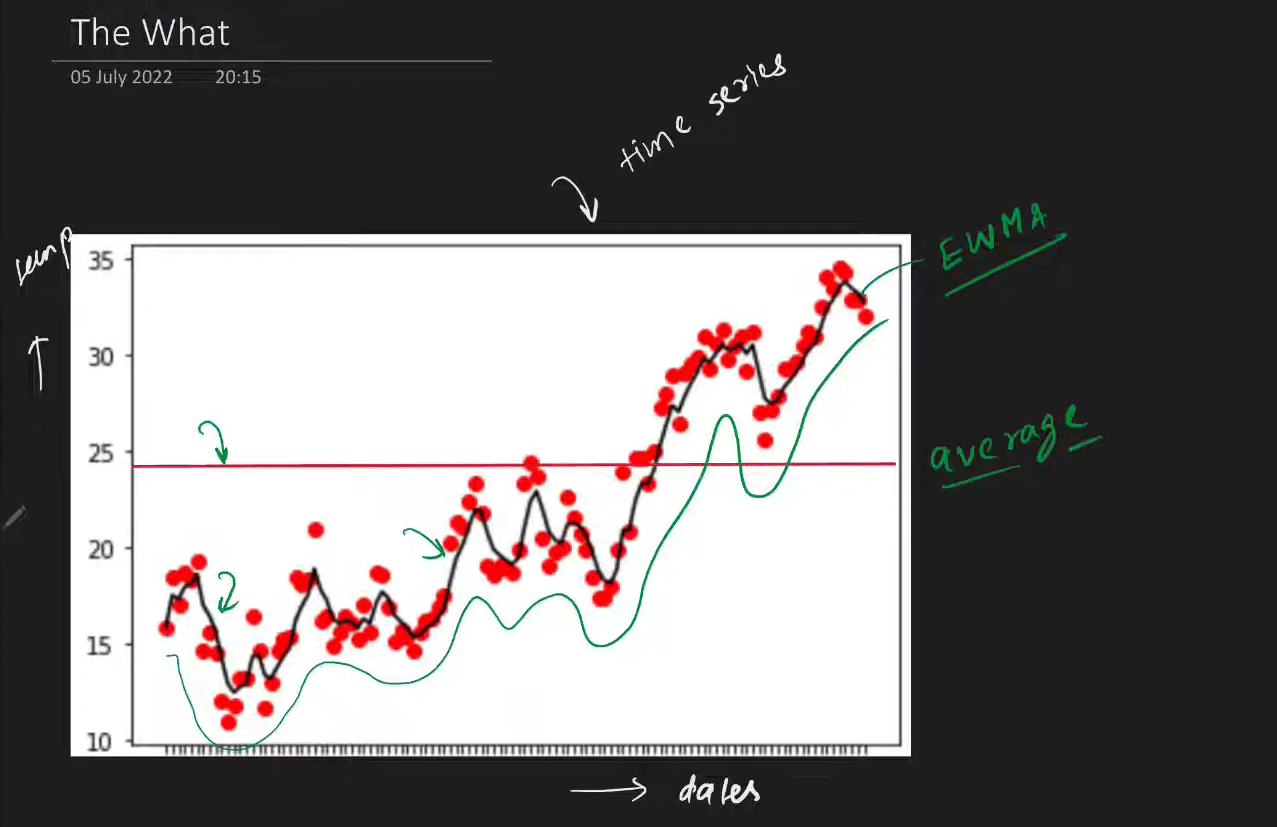

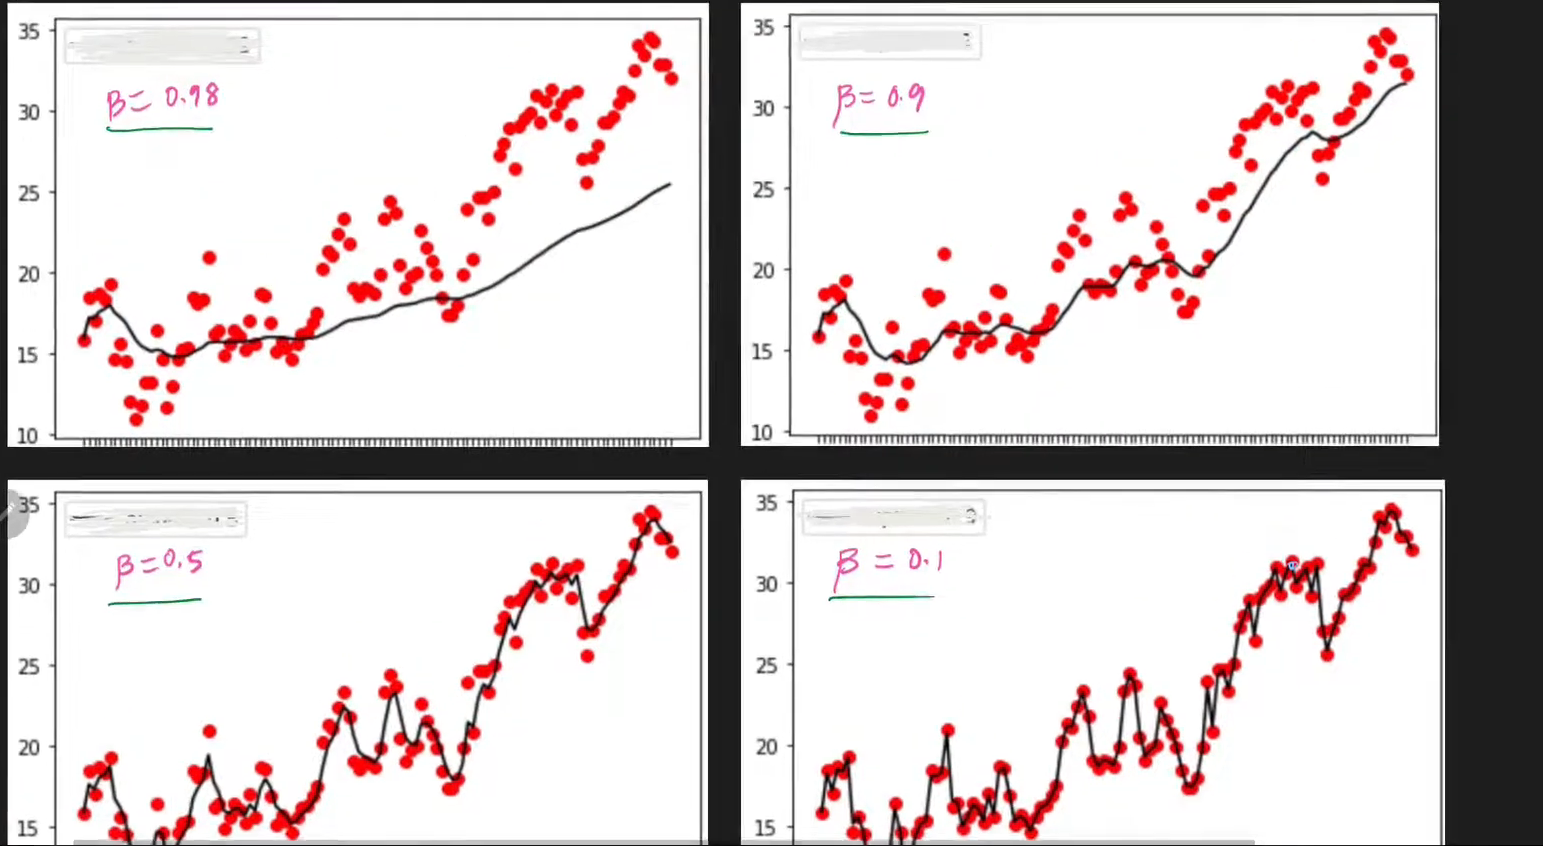


---

## 1. **What is EWMA?**

The **Exponentially Weighted Moving Average** is a way to keep track of a number that changes over time, while giving **more importance to recent values** and **less to older values**.

It’s often used in **deep learning** for:

* Smoothing noisy training curves
* Storing a running average of gradients in optimizers like **Adam** or **RMSProp**
* Keeping a stable copy of model weights for evaluation

---

## 2. **The Formula**

If $x_t$ is the value at time step $t$, and $v_t$ is the moving average, we write:

$$
v_t = \beta v_{t-1} + (1 - \beta) x_t
$$

* **$\beta$** (beta) is the smoothing factor, between **0** and **1**
* A larger $\beta$ makes the average **smoother** but slower to react
* A smaller $\beta$ makes it **more responsive** but noisier

---

## 3. **How it Works**

We can open the formula to see where the weights come from:

$$
v_t = (1 - \beta) x_t + (1 - \beta)\beta x_{t-1} + (1 - \beta)\beta^2 x_{t-2} + \dots
$$

This means:

* The newest value gets weight $1 - \beta$
* The one before that gets $(1 - \beta)\beta$
* And so on…
  The weights get smaller exponentially, so **recent values matter more**.

---

## 4. **Effective Window Size**

The “memory length” of EWMA depends on $\beta$:

$$
N_{\text{effective}} \approx \frac{1}{1 - \beta}
$$

Example:

* If $\beta = 0.9$, it’s like remembering about **10 past steps**
* If $\beta = 0.99$, it’s like remembering **100 steps**

---

## 5. **Bias in Early Steps**

If we start with $v_0 = 0$, the early values of $v_t$ will be **too small** because the average starts from zero.

To fix this, we use **bias correction**:

$$
\hat{v}_t = \frac{v_t}{1 - \beta^t}
$$

This is what **Adam optimizer** does for gradients.

---

## 6. **Why it’s Important in Deep Learning**

1. **Optimizer momentum**
   EWMA is used to remember gradients over time.
   Example (Adam first moment):

   $$
   m_t = \beta m_{t-1} + (1 - \beta) g_t
   $$

2. **Smoothing training curves**
   Raw loss curves bounce a lot. EWMA smooths them.

3. **Weight EMA**
   Sometimes we keep a moving average of model weights for better evaluation stability.

---

## 7. **Special Cases**

* $\beta = 0$: no smoothing, just take the latest value
* $\beta$ close to 1: very smooth, reacts slowly
* Difference from a simple moving average: SMA has equal weights over a fixed window, EWMA has infinite window but exponentially smaller weights for old values

---

💡 **Main idea**:
EWMA is like having a memory that slowly forgets the past at a constant rate. This is perfect for deep learning, where we want to adapt to changes but still keep some memory of what happened before.

---




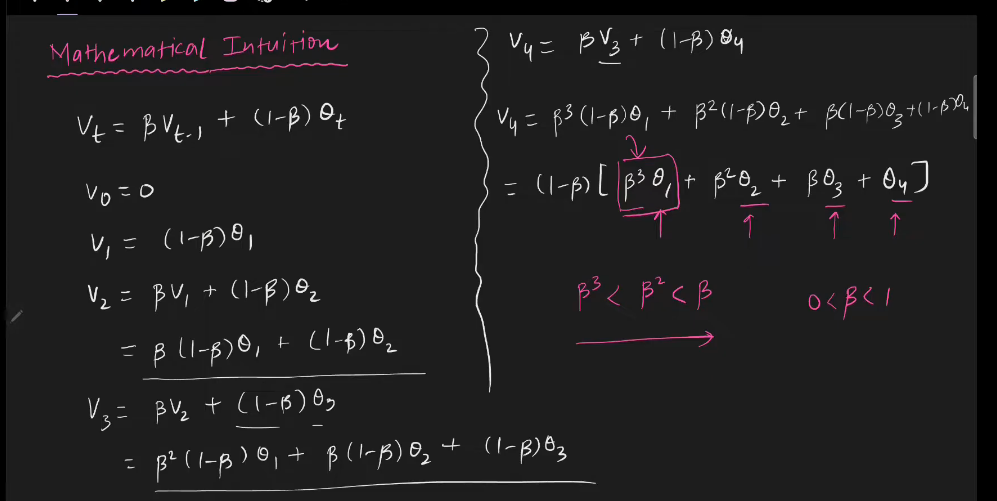

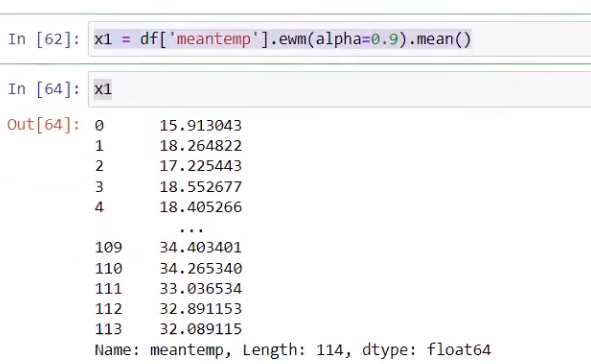

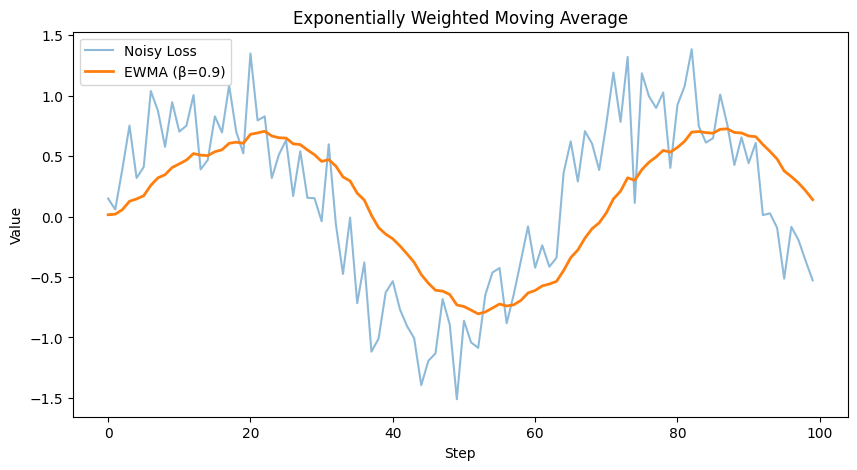

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated noisy loss values
np.random.seed(42)
steps = np.arange(100)
loss = np.sin(steps / 10) + np.random.normal(scale=0.3, size=100)

# EWMA parameters
beta = 0.9
ema = 0
ema_values = []

# Compute EWMA
for x in loss:
    ema = beta * ema + (1 - beta) * x
    ema_values.append(ema)

# Plot
plt.figure(figsize=(10,5))
plt.plot(steps, loss, label="Noisy Loss", alpha=0.5)
plt.plot(steps, ema_values, label=f"EWMA (β={beta})", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Value")
plt.title("Exponentially Weighted Moving Average")
plt.legend()
plt.show()


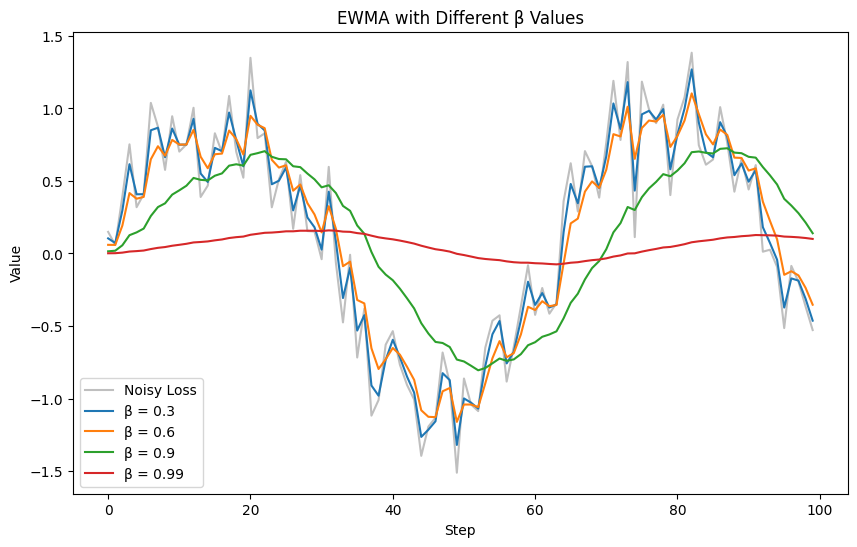

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated noisy loss values
np.random.seed(42)
steps = np.arange(100)
loss = np.sin(steps / 10) + np.random.normal(scale=0.3, size=100)

# Different beta values to test
betas = [0.3, 0.6, 0.9, 0.99]

plt.figure(figsize=(10,6))
plt.plot(steps, loss, label="Noisy Loss", color="gray", alpha=0.5)

# Compute EWMA for each beta
for beta in betas:
    ema = 0
    ema_values = []
    for x in loss:
        ema = beta * ema + (1 - beta) * x
        ema_values.append(ema)
    plt.plot(steps, ema_values, label=f"β = {beta}")

# Labels and legend
plt.xlabel("Step")
plt.ylabel("Value")
plt.title("EWMA with Different β Values")
plt.legend()
plt.show()
